# HPOBench Random Forest: SMAC surrogate leaf-size comparison

Ten SMAC seeds per surrogate `min_samples_leaf` value on task 10101.

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

HERE = Path.cwd()
if HERE.name != "01_initial" or HERE.parent.name != "random_forest":
    HERE = Path("experiments/HPOBench/random_forest/01_initial").resolve()

paths = sorted((HERE / "smac_output").glob("leaf_*/*/trajectory.json"))
results = [json.loads(path.read_text()) for path in paths]
if not results:
    raise FileNotFoundError("No trajectories found. Run run_smac_rf.py first.")
print(f"Loaded {len(results)}/30 trajectories.")

rows = []
for result in results:
    rows.extend({
        "min_samples_leaf": result["min_samples_leaf"],
        "smac_seed": result["smac_seed"],
        "iteration": iteration,
        "best_so_far": best,
    } for iteration, best in zip(result["iteration"], result["best_so_far"]))
trajectories = pd.DataFrame(rows)

Loaded 30/30 trajectories.


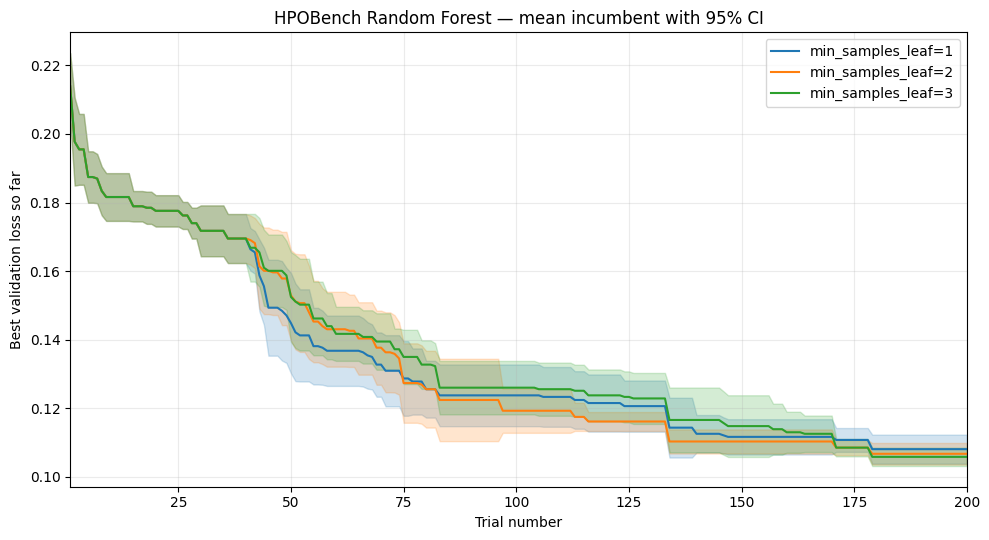

In [3]:
summary = (
    trajectories.groupby(["min_samples_leaf", "iteration"])["best_so_far"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
summary["ci95"] = 1.96 * summary["std"].fillna(0) / np.sqrt(summary["count"])
colors = {1: "tab:blue", 2: "tab:orange", 3: "tab:green"}

fig, ax = plt.subplots(figsize=(10, 5.5))
for leaf in (1, 2, 3):
    data = summary[summary["min_samples_leaf"] == leaf]
    x = data["iteration"].to_numpy()
    mean = data["mean"].to_numpy()
    ci = data["ci95"].to_numpy()
    ax.plot(x, mean, color=colors[leaf], label=f"min_samples_leaf={leaf}")
    ax.fill_between(x, mean - ci, mean + ci, color=colors[leaf], alpha=0.2)
ax.set(
    title="HPOBench Random Forest — mean incumbent with 95% CI",
    xlabel="Trial number",
    ylabel="Best validation loss so far",
    xlim=(1, 200),
)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

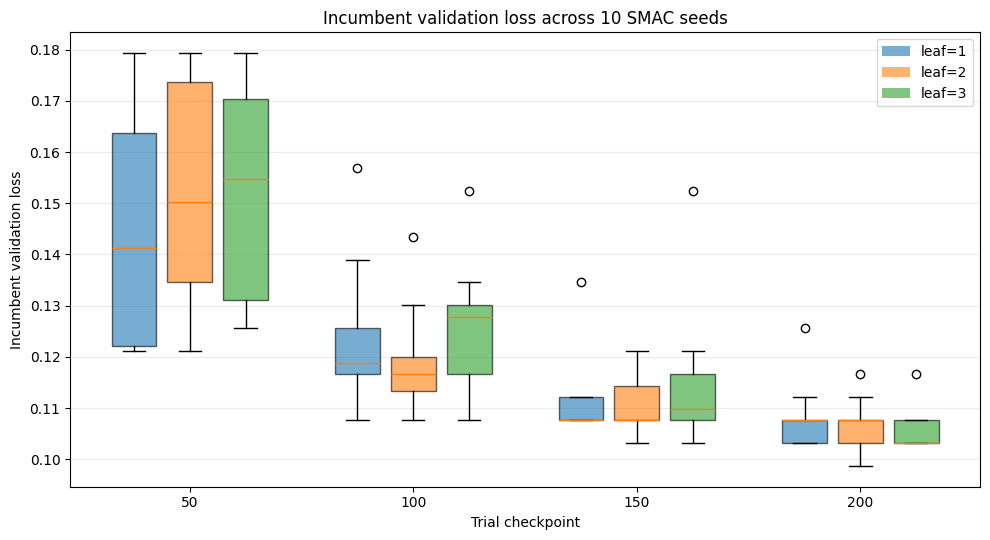

,count,mean,std,min,25%,50%,75%,max
min_samples_leaf,,,,,,,,
1,10.0,0.108072,0.006834,0.103139,0.103139,0.107623,0.107623,0.125561
2,10.0,0.106726,0.005091,0.098655,0.103139,0.107623,0.107623,0.116592
3,10.0,0.105830,0.004332,0.103139,0.103139,0.103139,0.107623,0.116592


In [4]:
checkpoints = (50, 100, 150, 200)
fig, ax = plt.subplots(figsize=(10, 5.5))
base = np.arange(len(checkpoints))
offsets = {1: -0.25, 2: 0.0, 3: 0.25}
for leaf in (1, 2, 3):
    values = [
        trajectories.loc[
            (trajectories["min_samples_leaf"] == leaf)
            & (trajectories["iteration"] == checkpoint),
            "best_so_far",
        ].to_numpy()
        for checkpoint in checkpoints
    ]
    boxes = ax.boxplot(
        values, positions=base + offsets[leaf], widths=0.2,
        patch_artist=True, manage_ticks=False,
    )
    for box in boxes["boxes"]:
        box.set(facecolor=colors[leaf], alpha=0.6)
ax.set(
    title="Incumbent validation loss across 10 SMAC seeds",
    xlabel="Trial checkpoint",
    ylabel="Incumbent validation loss",
    xticks=base,
    xticklabels=checkpoints,
)
ax.legend(handles=[Patch(facecolor=colors[x], alpha=0.6, label=f"leaf={x}") for x in (1, 2, 3)])
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

trajectories[trajectories["iteration"] == 200].groupby("min_samples_leaf")["best_so_far"].describe()